In [1]:
#Plotting
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid')


#File handling
import glob
import numpy as np
import pandas as pd
import re

#Stats
import statistics as stats

#wd
import os
base = os.getcwd()


In [22]:
# Enter results directory
os.chdir(f'{base}/UMAP_outputs/PLGA_NAGL_mono_30-07-2025_13_31_44_UMAP_data')

In [24]:
# Import summary table of best silhouette score and cluster number results
best_results = pd.read_csv('best_cluster_results.csv')
# find all csv files corresponding to the best silhouette score and cluster number results
best_csv_files = []
for i in range(len(best_results)):
    cluster_num = best_results['best_n_clusters'][i]
    silhouette_score = best_results['best_silhouette_score'][i]
    # find csv files that match the cluster number and silhouette score
    best_csv_files.append(f'chain_{i}_clusters_{cluster_num}.csv')
best_csv_files

['chain_0_clusters_10.csv',
 'chain_1_clusters_2.csv',
 'chain_2_clusters_5.csv',
 'chain_3_clusters_5.csv',
 'chain_4_clusters_7.csv',
 'chain_5_clusters_7.csv',
 'chain_6_clusters_9.csv',
 'chain_7_clusters_5.csv',
 'chain_8_clusters_4.csv',
 'chain_9_clusters_3.csv',
 'chain_10_clusters_2.csv',
 'chain_11_clusters_7.csv',
 'chain_12_clusters_2.csv',
 'chain_13_clusters_8.csv',
 'chain_14_clusters_3.csv',
 'chain_15_clusters_2.csv',
 'chain_16_clusters_4.csv',
 'chain_17_clusters_5.csv',
 'chain_18_clusters_7.csv',
 'chain_19_clusters_5.csv',
 'chain_20_clusters_5.csv',
 'chain_21_clusters_9.csv',
 'chain_22_clusters_2.csv',
 'chain_23_clusters_4.csv',
 'chain_24_clusters_2.csv']

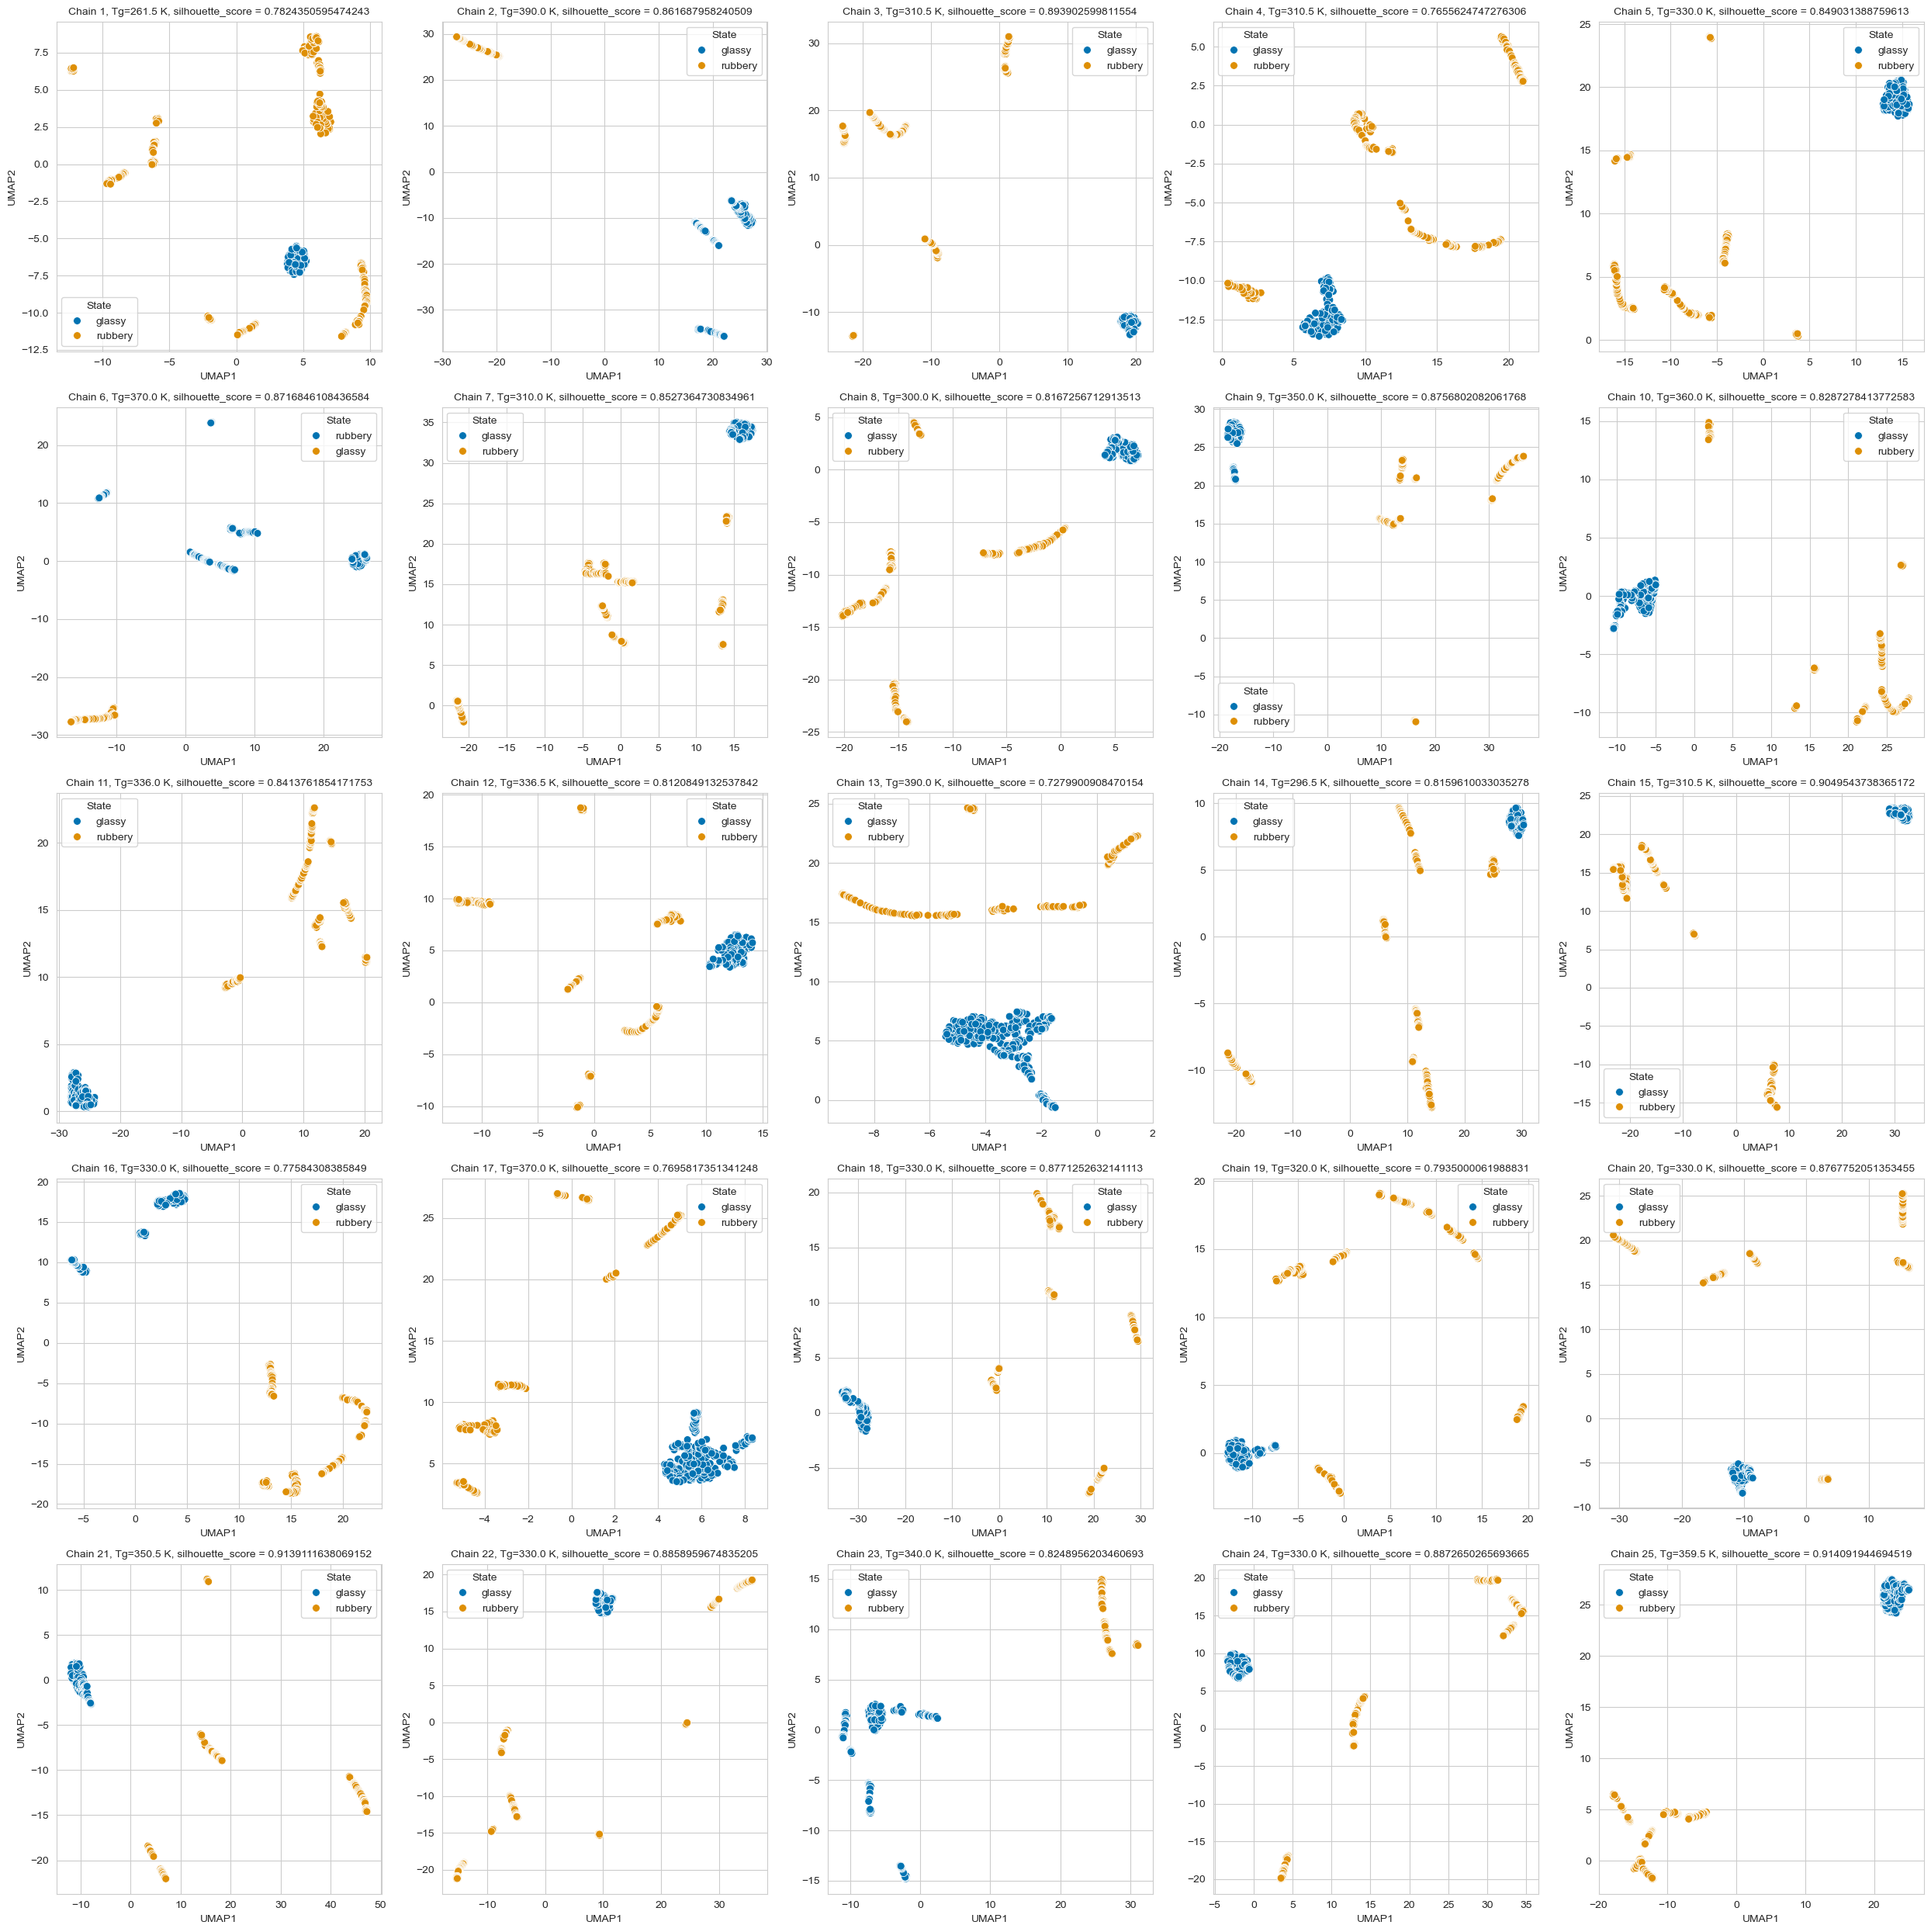

In [25]:
# Plot clustering results over UMAP projection
fig, axes = plt.subplots(5, 5, figsize=(25, 25)) 
axes = axes.flatten()

for idx, i in enumerate(best_csv_files):
    tg = best_results.iloc[idx]['best_Tg']
    sil_score = best_results.iloc[idx]['best_silhouette_score']
    temp_df = pd.read_csv(i)
    temp_df['temp'] = np.arange(200, 500.5, 0.5)
    temp_df.set_index('temp', inplace=True)
    
    ax = axes[idx]
    sns.scatterplot(data=temp_df, x='UMAP1', y='UMAP2', hue='State', palette='colorblind', s=50, ax=ax)
    ax.set_title(f'Chain {idx+1}, Tg={tg} K, silhouette_score = {sil_score}', fontsize=10)

for ax in axes[len(best_csv_files[:25]):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

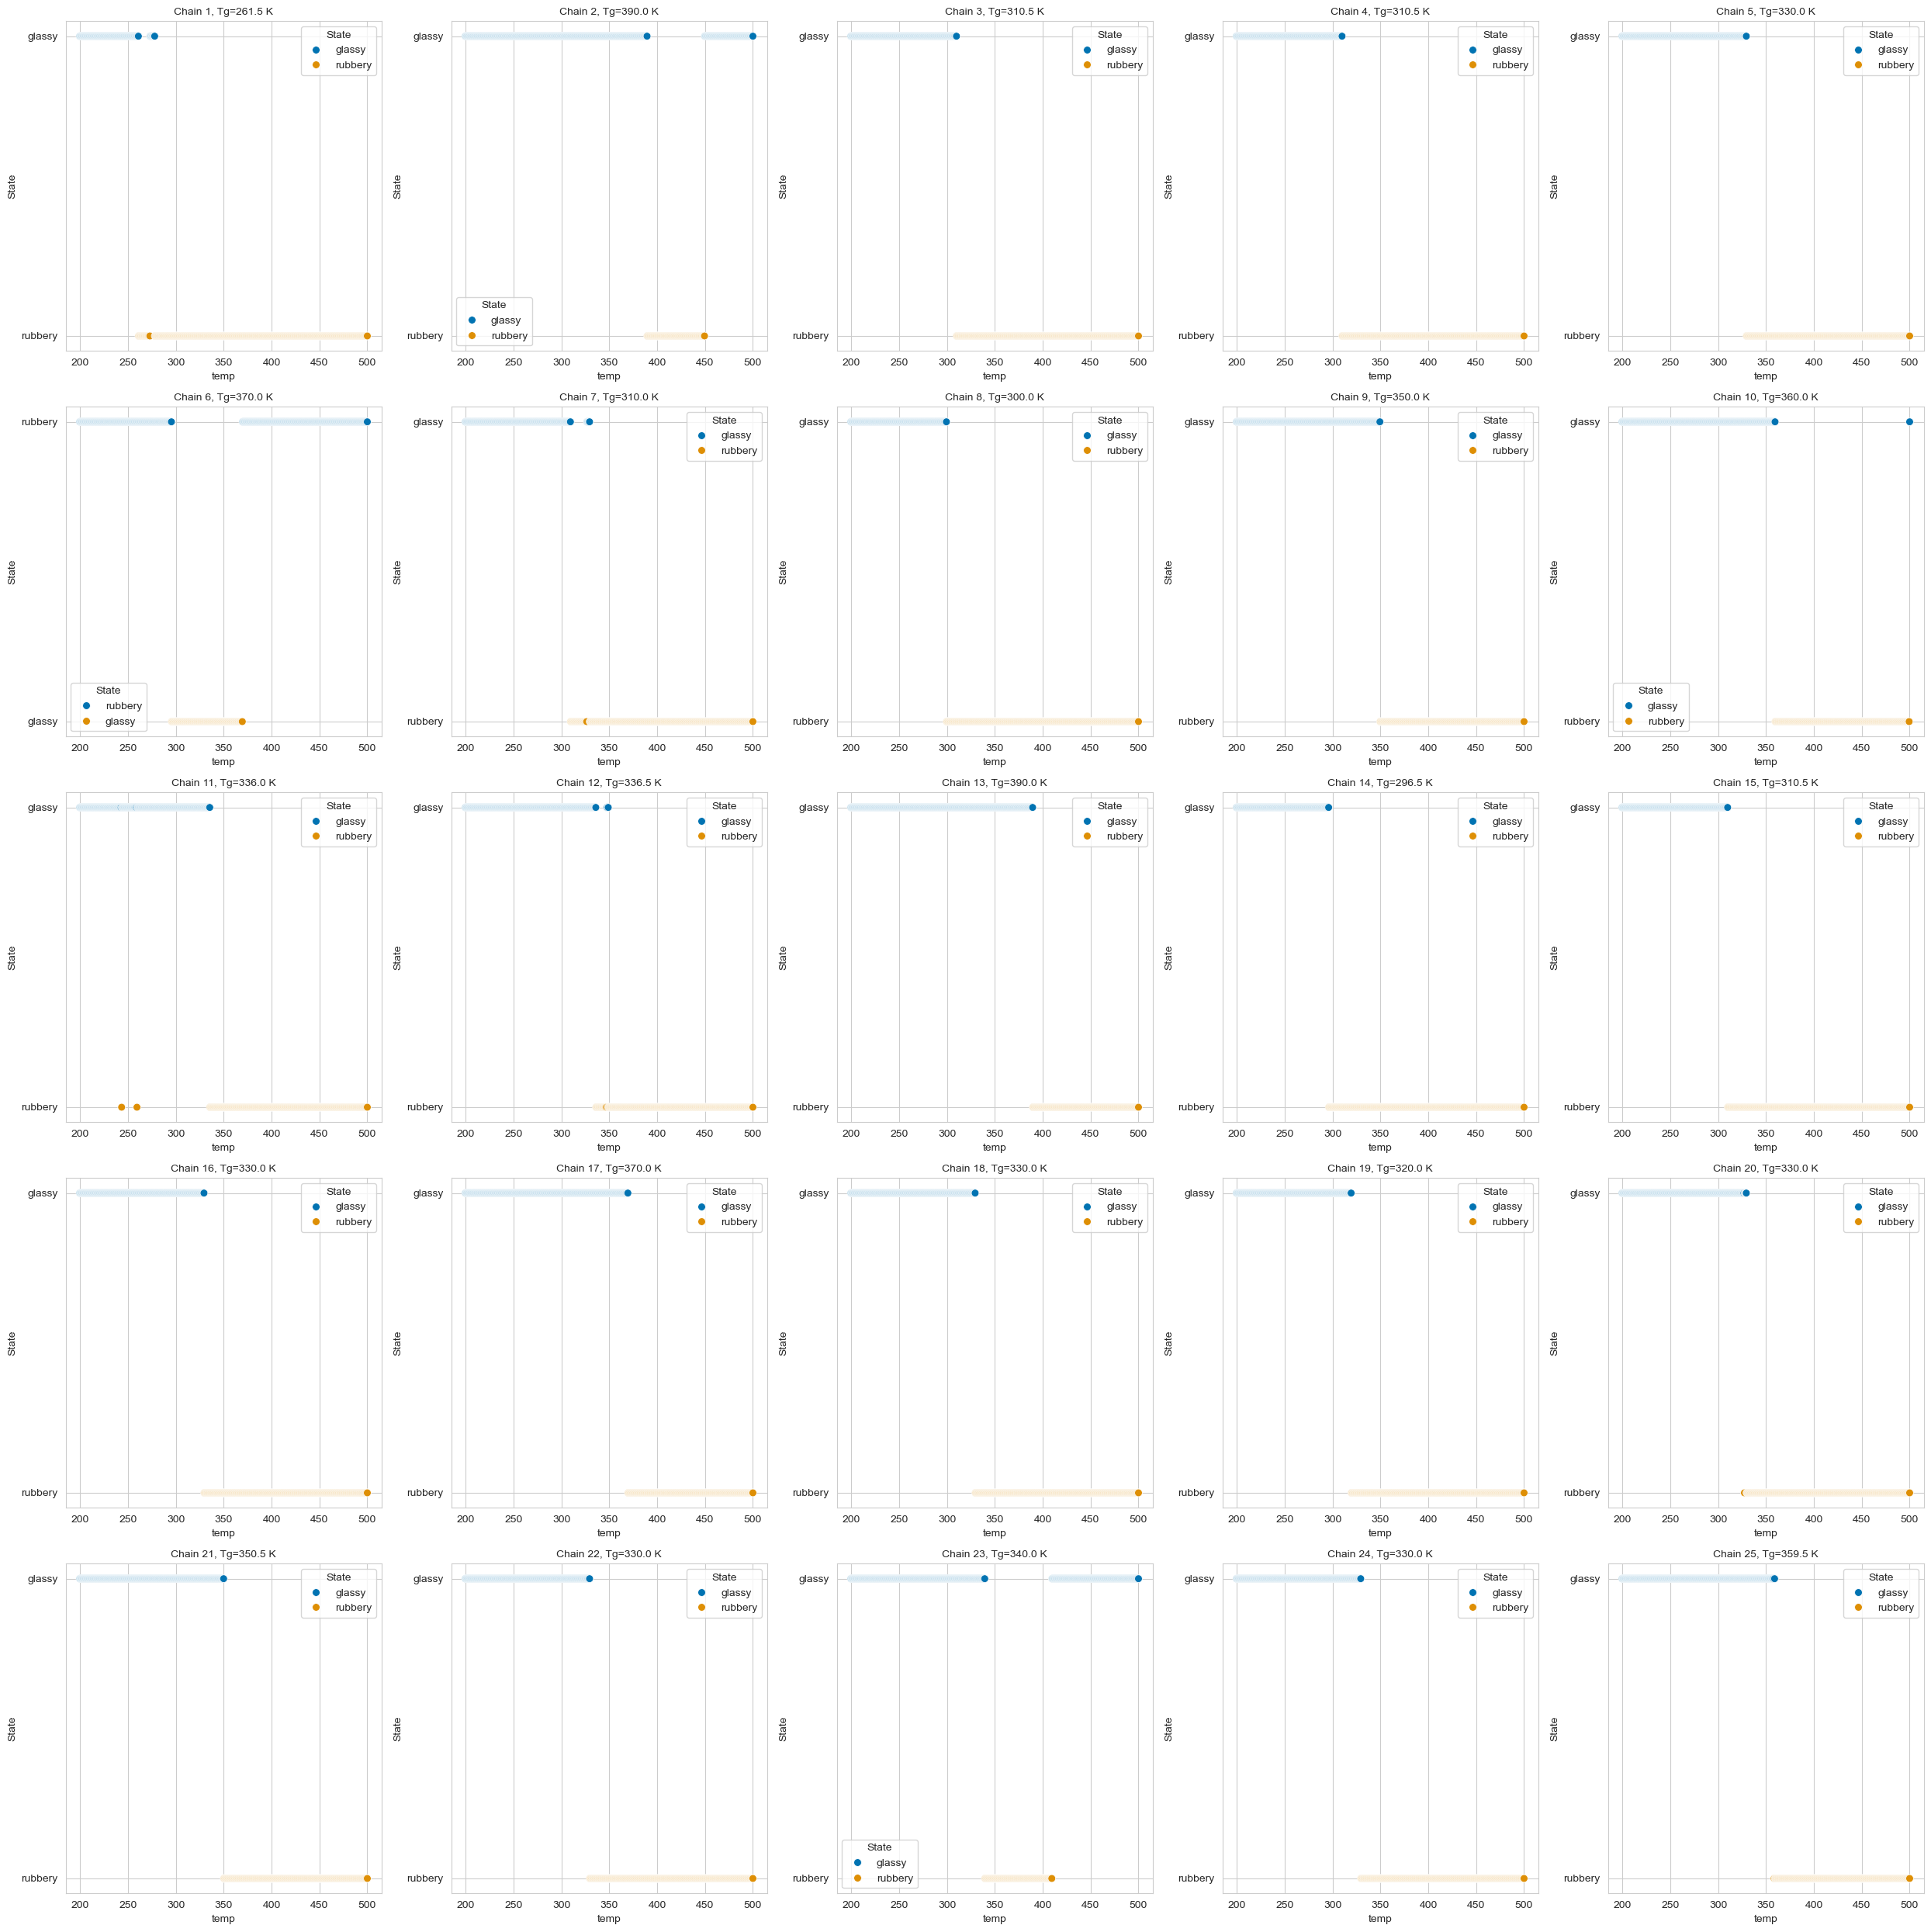

In [26]:
# Plot clustering results vs. temperature
fig, axes = plt.subplots(5, 5, figsize=(25, 25))
axes = axes.flatten()

for idx, i in enumerate(best_csv_files):     
    tg = best_results.iloc[idx]['best_Tg']
    temp_df = pd.read_csv(i)
    temp_df['temp'] = np.arange(200, 500.5, 0.5)
    temp_df.set_index('temp', inplace=True)
    
    ax = axes[idx] 
    sns.scatterplot(data=temp_df, x='temp', y='State', hue='State', palette='colorblind', s=50, ax=ax)
    ax.set_title(f'Chain {idx+1}, Tg={tg} K', fontsize=10)  # Add a title to each subplot

# Remove any unused subplots
for ax in axes[len(best_csv_files):]:
    ax.axis('off')

plt.tight_layout()  # Adjust layout to prevent overlap
plt.show()

/var/folders/82/29hpsrjj62ndyvrkx204dy600000gn/T/ipykernel_3494/1089982773.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper right")


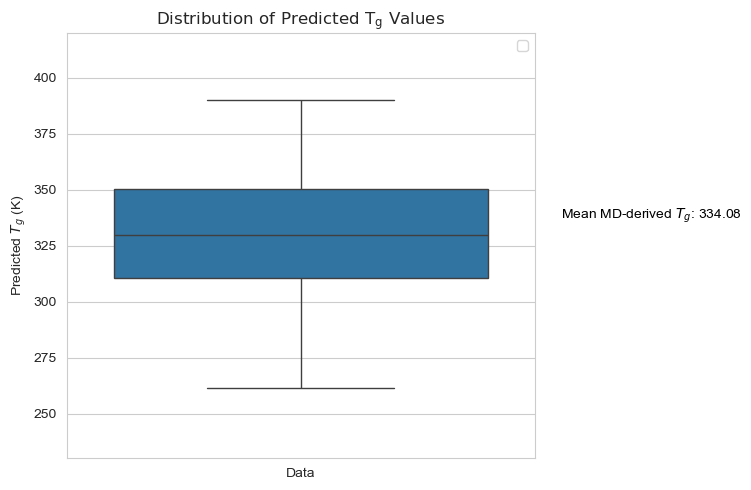

In [32]:
# Plot Tg value spread in melt
# Load the Tg values
tgs_list = best_results['best_Tg']

# Create a DataFrame for plotting
data = pd.DataFrame({
    'Tg': tgs_list,
    'Group': ['Data'] * len(tgs_list)
})

# boxplot
plt.figure(figsize=(8, 5))
sns.boxplot(x='Group', y='Tg', data=data)

# Annotate the mean value
mean_tg = stats.mean(tgs_list)
plt.text(0.75, mean_tg, f"Mean MD-derived $T_g$: {mean_tg:.2f}", 
         color="black", ha="center", va="bottom", fontsize=10)

# Add labels and title
plt.ylabel('Predicted $T_g$ (K)')
plt.xlabel("")
plt.ylim(230, 420)
plt.title(r"$\mathrm{Distribution\ of\ Predicted\ T_g\ Values}$")
plt.legend(loc="upper right")
plt.tight_layout()

# Show the plot
plt.show()